In [1]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
from matplotlib import ticker
import astropy.units as un
from astropy.cosmology import Planck18
import astropy.constants as const
import seaborn as sns
import numpy as np
from scipy.integrate import simpson, quad, dblquad
from scipy.interpolate import interp1d, griddata
from scipy.optimize import fsolve

from tqdm import tqdm

import mpmath as mp

import halomod as hd
import hmf
import scipy.special as sp
import timeit


matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings

from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

## REMINDER: ALL HMF IS IN /h units, so M should be Msun/h etc. 

In [2]:
# need to define concentration
class Bhattacharya12(hd.concentration.CMRelation):
    _defaults = {"a": None, "b": None, "c": None}
    native_mdefs = (hmf.mass_definitions.SOCritical(), hmf.mass_definitions.SOVirial())

    def cm(self, m, z):
        set_params = {
            "200c": {
                "a": 0.54,
                "b": 5.9,
                "c": -0.35,
                },
            "178c": {
                "a": 0.9,
                "b": 7.7,
                "c": -0.29,
                },
            "vir": {
                "a": 0.9,
                "b": 7.7,
                "c": -0.29,
                }
        }
        parameter_set = set_params.get(self.mdef.colossus_name, set_params["200c"])
        nu = self.growth.growth_factor(z)**-1 * (1.12 * (m/5e13)**0.3 + 0.53)
        return self.growth.growth_factor(z)**parameter_set["a"] * parameter_set["b"] * nu**parameter_set["c"]

In [ ]:
kappa = 5.7e-38 # eV**2

# arrays of redshift, halo masses, and wavenumbers
zs = np.linspace(0.005, 4, 50) 
ms = np.geomspace(1e11, 1e17, 100,) #Msolar
# ms = np.geomspace(7e8, 3.5e15, 100)/Planck18.h #Msun
dlogm = np.diff(np.log10(ms*Planck18.h))[0]
ks = np.geomspace(1e-4, 1e3, 10**4,) # Mpc**-1
dlnk = np.diff(np.log(ks/Planck18.h))[0]

hm = hd.DMHaloModel(
    z=0.0,
    Mmin=np.log10(ms[0]*Planck18.h), #Msun/h
    Mmax=np.log10(ms[-1]*Planck18.h)+ dlogm, #Msun/h
    dlog10m=dlogm,
    lnk_min=np.log(ks[0]/Planck18.h), #h/Mpc
    lnk_max=np.log(ks[-1]/Planck18.h) + dlnk, #h / Mpc
    dlnk=dlnk,
    halo_concentration_model="Bhattacharya12",
    bias_model="Tinker10",
    # halo_overdensity_crit=200,
    # disable_mass_conversion=True,
    hmf_model="Tinker08",
    mdef_model=hmf.halos.mass_definitions.SOVirial,
    # mdef_params={"overdensity":200},
    cosmo_params={"m_nu":[0,0,0], },
    )


/projectnb/darkcosmo/ebaker/.conda/envs/21cmfastv4/lib/python3.12/site-packages/hmf/density_field/transfer_models.py:233: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


In [4]:
rhocritz = Planck18.critical_density(zs).to(un.Msun / un.Mpc**3).value # Msun / Mpc**3

bias = np.empty((len(zs), len(ms)))
n       = np.empty((len(zs), len(ms)))
cs = np.empty((len(zs), len(ms)))
rvirs = np.empty((len(zs), len(ms)))
R200s = np.empty((len(zs), len(ms)))
m200s = np.empty((len(zs), len(ms)))
c200s = np.empty((len(zs), len(ms)))
lin_power = np.empty((len(zs), len(ks)))
delta_vir = 178 #rho_c 

for i, z in tqdm(enumerate(zs)):
    hm.z = z    
    n[i, :] = hm.dndm * Planck18.h**4
    bias[i, :] = hm.halo_bias #dimless
    cs[i, :] = hm.cmz_relation #dimless
    lin_power[i, :] = hm.linear_power_fnc(ks/Planck18.h) /Planck18.h**3 # conver to Mpc^3
    for j, m in enumerate(ms):
        # rvirs[i, j] = fsolve(lambda r: hm.halo_profile.rho(r, m * Planck18.h, coord="r") * Planck18.h**2 - rhocritz[i] * delta_vir, 0.0001)[0] / Planck18.h
        rvirs[i, j] = hm.halo_profile.halo_mass_to_radius(m * Planck18.h, at_z=z)/Planck18.h # Mpc
        m200s[i,j], R200s[i,j], c200s[i,j] = hm.mdef.change_definition(m * Planck18.h, 
                                                                       mdef=hmf.halos.mass_definitions.SOCritical(overdensity=200), 
                                                                       c=cs[i,j], 
                                                                       z=z,
                                                                       cosmo=Planck18)
m200s /= Planck18.h
R200s /= Planck18.h

33it [00:05,  5.90it/s]/projectnb/darkcosmo/ebaker/.conda/envs/21cmfastv4/lib/python3.12/site-packages/hmf/mass_function/hmf.py:396: UserWarning: Nonlinear mass outside mass range
  warnings.warn("Nonlinear mass outside mass range")
50it [00:08,  5.79it/s]


In [20]:
# R200 = rvir
# x is in units of x/xc$
# rs = R200[...,None] * xs[None, None, :] / 2


rs = np.linspace(1e-12, 1.1 * rvirs, int(1e4)) # Mpc
rs = np.moveaxis(rs, 0, -1)

# old gas profile
# def rho_gas(r, z, m, R200):
#     x = r / R200
#     p = {"rho0": {
#             "a": 4e3,
#             "b": 0.29,
#             "c": -0.66,
#         },
#          "alpha": {
#             "a": 0.88,
#             "b": -0.03,
#             "c": 0.19,
#          },
#          "beta": {
#             "a": 3.83,
#             "b": 0.04,
#             "c": -0.025,
#          }
#          }
#     gamma = -0.2
#     xc = 0.5
#     rho0  = p["rho0"]["a"]  * (m[..., None] / 10**14)**p["rho0"]["b"]  * (1+z[:, None, None])**p["rho0"]["c"]
#     alpha = p["alpha"]["a"] * (m[..., None] / 10**14)**p["alpha"]["b"] * (1+z[:, None, None])**p["alpha"]["c"]
#     beta  = p["beta"]["a"]  * (m[..., None] / 10**14)**p["beta"]["b"]  * (1+z[:, None, None])**p["beta"]["c"]
#     return Planck18.Ob0 / Planck18.Om0 * rhocritz[:, None, None] * rho0 * (x /xc)**gamma * (1 + (x/xc)**alpha)**(-(beta+gamma)/alpha)

rho_halo = ms[None, :] / (4 / 3 * np.pi * rvirs**3)
ANFW     = np.log(1 + cs) - cs / (1 + cs)
x        = rs / rvirs[..., None]
rho_gases = Planck18.Ob0 / Planck18.Om0 * rho_halo[..., None] / (3 * ANFW[..., None] * x * (cs[..., None]**-1 + x)**2)

# rho_gases = rho_gas(rs, zs, m200s, R200s[..., None])
mgamma2 = kappa * rho_gases
Plin_z1_z2 = np.sqrt(lin_power[None, :] * lin_power[:, None])


In [21]:
# function to find nearest value in array to given value
# mA_list = np.array([5.200e-13])
mA = 1e-12
# mA = 6e-13
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx], idx

drho_drs = np.empty([len(zs), len(ms)]) # these match McCarthy code seemingly
r_convs = np.empty([len(zs),len(ms)]) # so do these, gas profile is working right. 
errs = np.empty([len(zs),len(ms)])


# iterate through redshifts and masses to find drho_dr when the conversion occurs
# this is inefficient but it's really fast so it doesn't matter
for i, z in enumerate(zs):
    for j, m in enumerate(ms):
        mA_index = find_nearest(np.sqrt(mgamma2[i, j, :]), mA)[1]
        drho_dr = np.abs(np.gradient(rho_gases[i,j,:], rs[i,j,:])) 
        drho_drs[i,j] =  np.abs(drho_dr[mA_index]) 
        r_convs[i,j] = rs[i,j,mA_index]
        if mA_index == len(mgamma2[i, j, :])-1:
            errs[i,j] = 0
        else:
            # errs[i,j] = np.abs((mgamma2[i, j, mA_index] - mA**2)/(mA**2))
            errs[i,j] = np.abs((mgamma2[i, j, mA_index] - mA**2)/(mA**2))


# compute quantities for determining the monopole
drho_drs /= 1.567e29  #unit conversion
chis = Planck18.comoving_distance(zs).to(un.Mpc).value # Mpc
theta_max_array = r_convs * (1+zs[:, None,]) / chis[:, None,] # these match 
u00 = (1+zs[:,None,])**2 * r_convs**2 / chis[:, None,]**2 / 2

epsilon = 1 #1e-7 #e-6
omega0 = 1#353e9 * 6.58e-16 * 2 * np.pi
const_prefact = epsilon**2 * mA**4 / omega0 
P = 2 * np.pi * const_prefact / kappa * (drho_drs)**-1 * np.heaviside(rvirs-r_convs, 0.5) / (1+zs[:, None,])  # these match
deta_dz = 4* np.pi * chis**2 / ((Planck18.H(zs) / const.c).to(un.Mpc**-1).value) * simpson(P * n * u00, x=ms, axis=1) # differs below z=2

In [10]:
def approx_ul0(l, theta_max):
    mu = -0.5
    arg = 1- theta_max**2/2
    return  np.pi * np.sqrt((2*l+1))/2 * theta_max**1.5 * (4-theta_max**2)**0.25 * 1/sp.gamma(1-mu) * ((1+arg)/(1-arg))**(mu/2) * sp.hyp2f1(-l, l+1,1-mu, (1-arg)/2)

def Cl_1halo_pirvu(l, theta_max):
    return 4 * np.pi / (2 * l + 1) * simpson(simpson(chis[:, None]**2  * approx_ul0(l, theta_max)**2 * P**2 * n, x=ms, axis=1), x=chis, axis=0)

ls = np.concatenate( [[0], np.geomspace(1, 9999, 99, dtype=int)])

ul0s = np.array([approx_ul0(l, theta_max_array) for l in ls])

bessel_arg1 = ks[None, None, :] * chis[:, None, None]
bessel_arg2 = ks[None, None, :] * chis[None, :, None]
integrand_without_js = Plin_z1_z2 * ks[None, None, :] ** 2

def hl(l):
    return (
        (2 * l + 1)
        / 2
        / np.pi**2
        * simpson(
            integrand_without_js
            * sp.spherical_jn(l, bessel_arg1)
            * sp.spherical_jn(l, bessel_arg2),
            x=ks,
            axis=-1,
        )
    )

interpolated_Plin = interp1d(ks, lin_power, axis=-1)

def Cl_2halo(l, theta_max):
    inner_int = simpson(n[None, :, :,  None,] 
                            * n[:, None, None, :,]
                            * bias[None, :, :,  None,] 
                            * bias[:, None, None, :,]
                            * P[None, :, :, None] 
                            * P[:, None, None, :]
                            * approx_ul0(l, theta_max)[None, :, :, None]
                            * approx_ul0(l, theta_max)[:, None, None, :]
                            ,
                        x=ms,
                        axis=-1,
                        )
    m_ints = simpson(inner_int,
                    x=ms,
                    axis=-1,
                    )
    z_ints = simpson(simpson(m_ints 
                            #  * Cl_lin(l)[..., None]
                             * hl(l) * 4 * np.pi / (2 * l + 1)
                             * chis[:, None,]**2
                             * chis[None, :,]**2,
                             x=chis,
                             axis=-1
                             ),
                    x=chis,
                    axis=-1
                    )    
    
    return 4 * np.pi / (2 * l + 1) * z_ints



def Cl_signal(l, theta_max):
    Cl1 = Cl_1halo_pirvu(l, theta_max)
    Cl2 = Cl_2halo(l, theta_max) 
    if l==0:
        print(l, Cl1, Cl2)
    Cl =  Cl1 + Cl2
    return Cl


ls = np.geomspace(1, 2000, 20, dtype=int)
test_auto_Cl = [Cl_signal(l, theta_max_array) for l in tqdm(ls)]
test_auto_Cl = np.array(test_auto_Cl)


100%|██████████| 20/20 [03:26<00:00, 10.35s/it]


0.1609576494590497


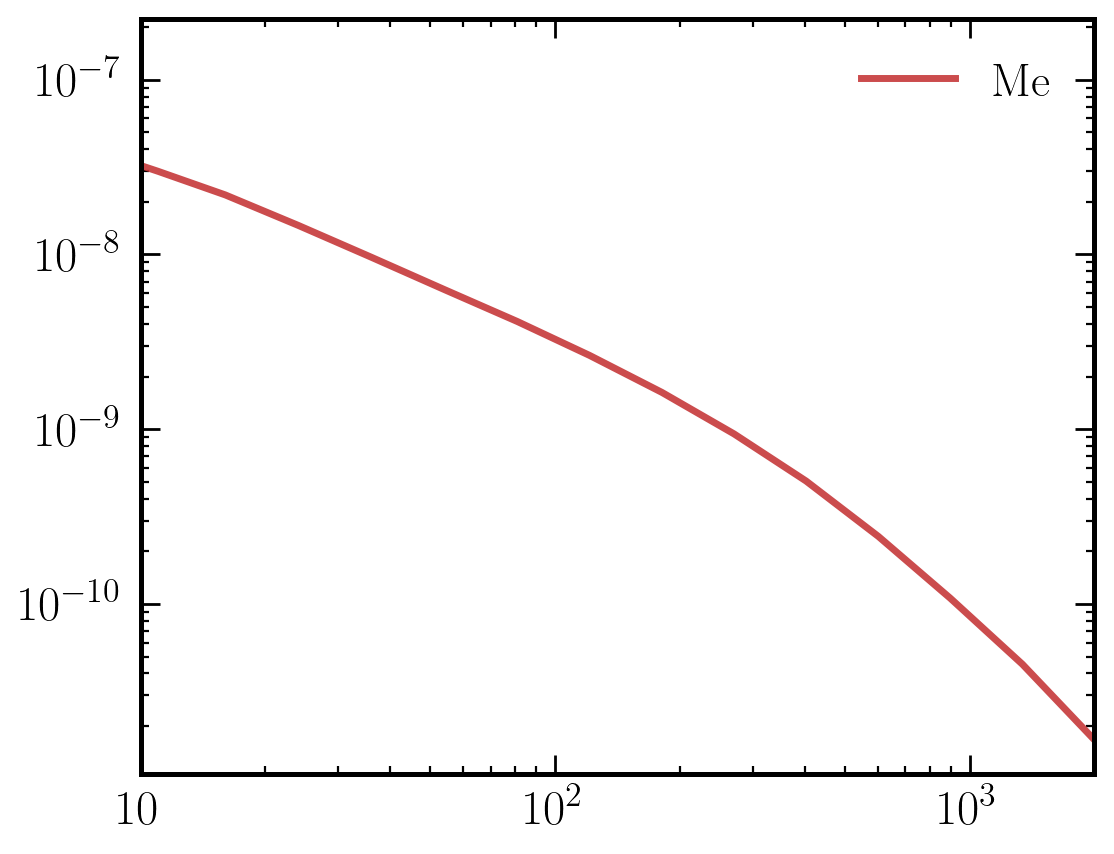

In [13]:
# paper_Cl_pp = np.genfromtxt("/home/bakerem/dark_photon_21cm_constraints/halo_data/data_from_papers/Cl_PP_mccarthy.csv", delimiter=',')
ls = np.geomspace(1, 2000, 20, dtype=int)
x = 2 * np.pi * 2.69 / 2.726
prefac = (1-np.exp(-x))/x
print(prefac)
plt.loglog(ls, test_auto_Cl * prefac**2 * (2.272e6)**2 * (2e-7)**4, label="Me")
# plt.plot(paper_Cl_pp[:, 0], paper_Cl_pp[:, 1], label="McCarthy", color='C1')
plt.xlim(10, 2000)
# plt.ylim(5e-7, 5e-3)
plt.legend()

## Galaxy HOD Model

In [ ]:
# dNgdz_dat =np.genfromtxt("/home/bakerem/dark_photon_21cm_constraints/halo_data/unwise_stuff/galaxy_dNg_dz.csv", delimiter=",").T
dNgdz_dat =np.genfromtxt("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/halo_data/unwise_stuff/galaxy_dNg_dz.csv", delimiter=",").T

# dNgdz_dat = np.genfromtxt("/home/bakerem/dark_photon_21cm_constraints/halo_data/unwise_stuff/normalised_dndz_cosmos_0.txt").T
dNgdz = interp1d(dNgdz_dat[0], dNgdz_dat[1], bounds_error=False, fill_value=0.0)
chis = Planck18.comoving_distance(zs).to(un.Mpc).value # Mpc

HOD_model = {
    "K22":{
        "logm_min": 11.97, # K22
        "sigma_logm": 0.687, # K22
        "alpha_s": 1.304, # K22
        "m1prime": 10**12.87, # K22
        "lambdaNFW": 1.087, # K22
    },
    "K23":{
        "logm_min": 11.86, # K23
        "sigma_logm": 0.020, # K23
        "alpha_s": 1.06, # K23
        "m1prime": 10**12.78, # K23
        "lambdaNFW": 1.80, # K23
    }
}

model = "K22"  # Change to "K23" for the K23 model
def Nc(m):
    logm_min = HOD_model[model]["logm_min"]
    sigma_logm = HOD_model[model]["sigma_logm"]
    return 0.5 * (1 + sp.erf((np.log10(m) - logm_min)/sigma_logm))

def Ns(m):
    alpha_s = HOD_model[model]["alpha_s"]
    m1prime = HOD_model[model]["m1prime"]
    return Nc(m) * (m / m1prime)**alpha_s

ngbar = simpson(n * (Nc(ms)[None, :] + Ns(ms)[None, :]), x=ms, axis=1)

def W(z):
    return ((Planck18.H(z)/ const.c) / Planck18.comoving_distance(z)**2).to(un.Mpc**-3).value * dNgdz(z)

def ug(Ws, Ncs, Nss, l):
    return Ws[:, None] * ngbar[:, None]**-1 * (Ncs[None, :] + Nss[None, :] * um(l))

def um(l):
    lambdaNFW = HOD_model[model]["lambdaNFW"]
    ks = (l + 0.5)/chis[:, None]
    q = ks * R200s / c200s * (1+zs[:, None])

    x = lambdaNFW * c200s
    qtilde = (1+ x) * q

    Si_q, Ci_q = sp.sici(q)
    Si_qtilde, Ci_qtilde = sp.sici(qtilde)

    fNFW = (np.log(1+x) - x/(1+x))**-1
    return (np.cos(q) * (Ci_qtilde - Ci_q) + np.sin(q) * (Si_qtilde - Si_q) - np.sin(x*q)/qtilde) * fNFW


def ug_mom2(Ws, Nss, l):
    return Ws[:, None]**2 * ngbar[:, None]**-2 * (Nss[None, :]**2 * um(l)**2 + 2 * Nss * um(l))

# precompute all these arrays for speed
Ncs = Nc(ms)
Nss = Ns(ms)
Ws = W(zs)


In [ ]:
# functions for computing the galaxy autopower spectrum
def Cl_1h_gg(l):
    return np.trapz(chis**2 / ((Planck18.H(zs) / const.c).to(un.Mpc**-1).value) * np.trapz(n * ug_mom2(Ws, Nss, l=l), x=ms, axis=1), x=zs, axis=0)

interp_lin_power = interp1d(ks, lin_power, axis=-1)
def Cl_2h_gg_limber(l):
    m_int = simpson(n * bias * ug(Ws, Ncs, Nss, l=l), x=ms, axis=1)
    Plin_at_zs = np.array([interp_lin_power((l+0.5)/chi)[chis == chi] for chi in chis]).reshape(zs.shape)
    return simpson(chis**2 / ((Planck18.H(zs) / const.c).to(un.Mpc**-1).value) * m_int**2 * Plin_at_zs, x=zs, axis=0)


In [ ]:
ls = np.arange(1, 2000, dtype=int)
paper_1h_gg_Cls = np.genfromtxt(f"/home/bakerem/dark_photon_21cm_constraints/halo_data/data_from_papers/Cl_gg_1halo_{model}.csv", delimiter=",").T
paper_2h_gg_Cls = np.genfromtxt(f"/home/bakerem/dark_photon_21cm_constraints/halo_data/data_from_papers/Cl_gg_2halo_{model}.csv", delimiter=",").T
ls_1h = paper_1h_gg_Cls[0].astype(int)
ls_2h = paper_2h_gg_Cls[0].astype(int)

C_gg_1hs = np.array([Cl_1h_gg(l) for l in tqdm(ls_1h)])
C_gg_2hs = np.array([Cl_2h_gg_limber(l) for l in tqdm(ls_1h)])

In [ ]:
plt.plot(ls_1h, C_gg_1hs * 1e5, color=cols_default[0],label="My 1-Halo")
plt.plot(ls_1h, C_gg_2hs * 1e5, color=cols_default[1],label="My 2-Halo")
# plt.plot(ls, C_gg_1hs * 1e5 + C_gg_2hs * 1e5, color=cols_default[2],label="My Total Halo")
plt.xlim(200, 1000)
# plt.ylim(0, 0.15)

plt.plot(ls_1h, paper_1h_gg_Cls[1], color=cols_default[2], ls="-.", label=f"{model} 1-Halo")
plt.plot(ls_2h, paper_2h_gg_Cls[1], color=cols_default[3], ls="-.", label=f"{model} 2-Halo")
# # plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C^{\rm gg}_\ell$")
plt.legend()
plt.yscale("log")

In [ ]:
def CgP_1h(l):
    return np.sqrt(4 * np.pi / (2 * l + 1)) * simpson(
        chis**2  * simpson(n * ug(Ws, Ncs, Nss, l=l) * P * approx_ul0(l, theta_max_array), 
                           x=ms, 
                           axis=1),
        x=chis,
        axis=0,
    )

def CgP_2h_limber(l):
    m_ints = simpson(P * approx_ul0(l, theta_max_array) * n * bias * simpson(n
                           * bias
                           * ug(Ws, Ncs, Nss, l=l)
                           , 
                           x=ms,
                           axis=1)[:, None], 
                           x=ms, 
                           axis=1)
    Plin_at_zs = np.array([interp_lin_power((l+0.5)/chi)[chis == chi] for chi in chis]).reshape(zs.shape)
    return np.sqrt(4 * np.pi / (2 * l + 1)) * simpson(chis**2 * m_ints * Plin_at_zs, 
                                                      x=chis, 
                                                      axis=0
                                                      )

In [ ]:
x = 2 * np.pi * 2.6969 / 2.725
prefac = (1-np.exp(-x))/x
C_gP_1hs = np.array([CgP_1h(l) for l in tqdm(ls)])
C_gP_2hs = np.array([CgP_2h_limber(l) for l in tqdm(ls)])

In [ ]:
plt.plot(ls, (ls) * prefac * (2.726e6) * (C_gP_1hs + C_gP_2hs), label="My code")
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell C^{\rm gP}_{\ell}$ [$\mu$K]")
# plt.xscale("log")